In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import difflib

In [3]:
# Load the dataset
movies_df = pd.read_csv('movies .csv')

# Select relevant features for recommendation
selected_features = ['genres', 'keywords', 'tagline', 'cast', 'director']

# Fill null values with empty strings to avoid errors in vectorization
for feature in selected_features:
    movies_df[feature] = movies_df[feature].fillna('')

# Combine features into a single column
movies_df['combined_features'] = movies_df['genres'] + ' ' + \
                                 movies_df['keywords'] + ' ' + \
                                 movies_df['tagline'] + ' ' + \
                                 movies_df['cast'] + ' ' + \
                                 movies_df['director']

movies_df[['title', 'combined_features']].head()

,title,combined_features
0,Avatar,Action Adventure Fantasy Science Fiction cultu...
1,Pirates of the Caribbean: At World's End,Adventure Fantasy Action ocean drug abuse exot...
2,Spectre,Action Adventure Crime spy based on novel secr...
3,The Dark Knight Rises,Action Crime Drama Thriller dc comics crime fi...
4,John Carter,Action Adventure Science Fiction based on nove...


In [4]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words='english')

# Transform the combined features into numerical vectors
feature_vectors = tfidf.fit_transform(movies_df['combined_features'])

# Calculate Cosine Similarity
similarity = cosine_similarity(feature_vectors)

print(f"Similarity Matrix Shape: {similarity.shape}")

Similarity Matrix Shape: (4803, 4803)


In [8]:
def get_recommendations(movie_name, num_recommendations=10):
    # Find the closest match for the movie name from the dataset
    list_of_all_titles = movies_df['title'].tolist()
    find_close_match = difflib.get_close_matches(movie_name, list_of_all_titles)
    
    if not find_close_match:
        return "Movie not found."
        
    close_match = find_close_match[0]
    print(f"Found Match: {close_match}\n")
    
    # Find the index of the movie in our dataframe
    index_of_the_movie = movies_df[movies_df.title == close_match]['index'].values[0]
    
    # Get similarity scores for all movies against this one
    similarity_score = list(enumerate(similarity[index_of_the_movie]))
    
    # Sort the movies based on similarity scores
    sorted_similar_movies = sorted(similarity_score, key=lambda x: x[1], reverse=True)
    
    # Print the recommendations
    print("Top Recommendations:\n")
    recommendations = []
    for i, movie in enumerate(sorted_similar_movies):
        if i == 0: continue # Skip the queried movie itself
        index = movie[0]
        title_from_index = movies_df[movies_df.index == index]['title'].values[0]
        recommendations.append(title_from_index)
        print(f"{len(recommendations)}. {title_from_index}")
        if len(recommendations) >= num_recommendations:
            break
            
    return recommendations

In [9]:
get_recommendations('Batman')

Found Match: Batman

Top Recommendations:

1. Batman Returns
2. Batman & Robin
3. The Dark Knight Rises
4. The Dark Knight
5. Batman Begins
6. A History of Violence
7. Beetlejuice
8. Mars Attacks!
9. Superman
10. The Mask


['Batman Returns',
 'Batman & Robin',
 'The Dark Knight Rises',
 'The Dark Knight',
 'Batman Begins',
 'A History of Violence',
 'Beetlejuice',
 'Mars Attacks!',
 'Superman',
 'The Mask']

In [10]:
get_recommendations('Interstellar')

Found Match: Interstellar

Top Recommendations:

1. The Dark Knight Rises
2. Dear Frankie
3. The Martian
4. The Matrix
5. The Matrix Revolutions
6. The Terminator
7. The Matrix Reloaded
8. Armageddon
9. The Tree of Life
10. Terminator Genisys


['The Dark Knight Rises',
 'Dear Frankie',
 'The Martian',
 'The Matrix',
 'The Matrix Revolutions',
 'The Terminator',
 'The Matrix Reloaded',
 'Armageddon',
 'The Tree of Life',
 'Terminator Genisys']

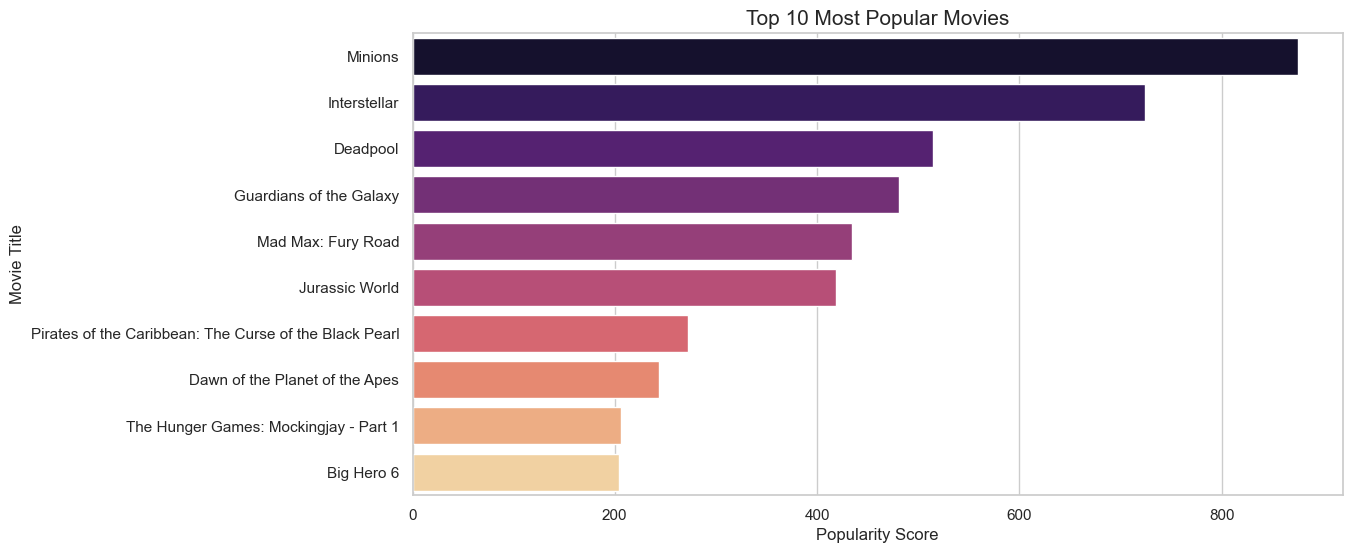

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Get top 10 popular movies
popular_movies = movies_df.sort_values('popularity', ascending=False).head(10)

# Plot
sns.barplot(x='popularity', y='title', data=popular_movies, palette='magma')
plt.title('Top 10 Most Popular Movies', fontsize=15)
plt.xlabel('Popularity Score')
plt.ylabel('Movie Title')
plt.show()

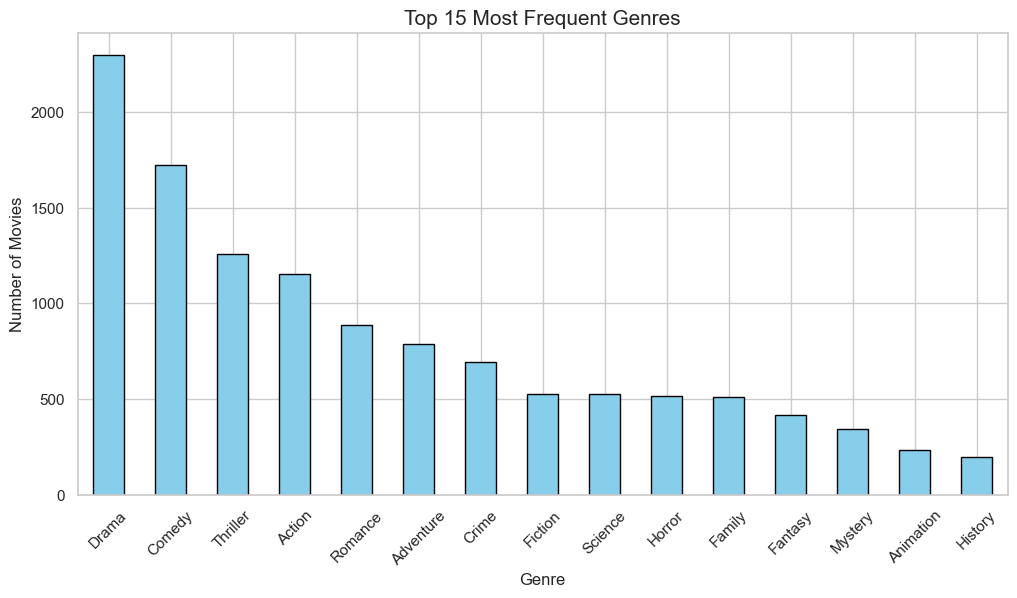

In [12]:
all_genres = " ".join(movies_df['genres'].fillna('')).split()
genre_counts = pd.Series(all_genres).value_counts().head(15)
# Plot
plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 15 Most Frequent Genres', fontsize=15)
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.show()

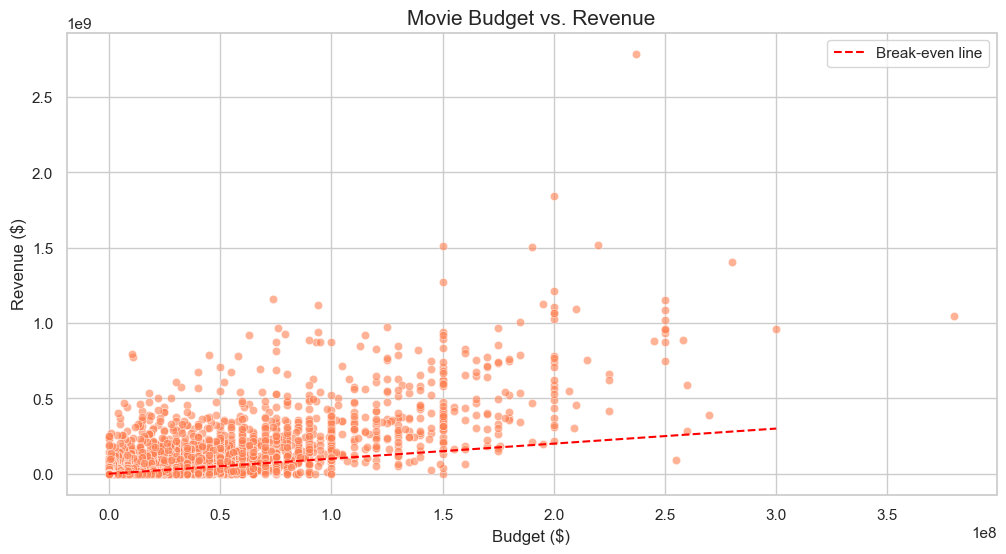

In [13]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='budget', y='revenue', data=movies_df, alpha=0.6, color='coral')
# Adding a reference line for break-even (where budget == revenue)
plt.plot([0, 3e8], [0, 3e8], color='red', linestyle='--', label='Break-even line')
plt.title('Movie Budget vs. Revenue', fontsize=15)
plt.xlabel('Budget ($)')
plt.ylabel('Revenue ($)')
plt.legend()
plt.show()